In [131]:
#Importing important libraries 
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, accuracy_score, precision_score, recall_score, f1_score
from sklearn.pipeline import Pipeline
from scipy import stats
from imblearn.over_sampling import SMOTE
#models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
import joblib

import warnings
warnings.filterwarnings('ignore') 

In [132]:
#loading and reading data
df = pd.read_csv('kidney_disease_dataset.csv')
df.head()

,Age of the patient,Blood pressure (mm/Hg),Specific gravity of urine,Albumin in urine,Sugar in urine,Red blood cells in urine,Pus cells in urine,Pus cell clumps in urine,Bacteria in urine,Random blood glucose level (mg/dl),...,Smoking status,Body Mass Index (BMI),Physical activity level,Duration of diabetes mellitus (years),Duration of hypertension (years),Cystatin C level,Urinary sediment microscopy results,C-reactive protein (CRP) level,Interleukin-6 (IL-6) level,Target
0,54,167,1.023,1,4,normal,abnormal,not present,not present,96,...,yes,25.3,low,4,16,0.67,normal,4.88,10.23,No_Disease
1,42,127,1.023,3,2,normal,normal,not present,present,73,...,no,20.6,moderate,3,13,0.55,abnormal,4.49,13.11,Low_Risk
2,38,148,1.016,0,0,abnormal,normal,not present,not present,77,...,no,38.4,high,11,23,2.37,abnormal,4.57,13.27,No_Disease
3,7,98,1.017,4,0,abnormal,normal,not present,present,225,...,no,24.7,high,24,3,2.54,abnormal,8.57,12.36,No_Disease
4,67,174,1.015,1,1,normal,abnormal,not present,not present,376,...,yes,17.6,high,22,24,1.90,normal,6.75,1.46,No_Disease


In [133]:
# Set seed for reproducibility
np.random.seed(42)

# Define custom missing value percentages
missing_config = {
    'Blood pressure (mm/Hg)': 0.1,           
    'Random blood glucose level (mg/dl)': 0.2,     
    'Serum creatinine (mg/dl)': 0.05         
}

# Introduce missing values per config
for col, pct in missing_config.items():
    if col in df.columns:
        n_missing = int(pct * len(df))
        missing_indices = np.random.choice(df.index, n_missing, replace=False)
        df.loc[missing_indices, col] = np.nan

# Saveing for further use
df.to_csv('kidney_disease_with_missing.csv', index=False)

In [134]:
print(df.isnull().sum())

Age of the patient                                0
Blood pressure (mm/Hg)                         2053
Specific gravity of urine                         0
Albumin in urine                                  0
Sugar in urine                                    0
Red blood cells in urine                          0
Pus cells in urine                                0
Pus cell clumps in urine                          0
Bacteria in urine                                 0
Random blood glucose level (mg/dl)             4107
Blood urea (mg/dl)                                0
Serum creatinine (mg/dl)                       1026
Sodium level (mEq/L)                              0
Potassium level (mEq/L)                           0
Hemoglobin level (gms)                            0
Packed cell volume (%)                            0
White blood cell count (cells/cumm)               0
Red blood cell count (millions/cumm)              0
Hypertension (yes/no)                             0
Diabetes mel

In [135]:
#checking null values an data info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20538 entries, 0 to 20537
Data columns (total 43 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   Age of the patient                           20538 non-null  int64  
 1   Blood pressure (mm/Hg)                       18485 non-null  float64
 2   Specific gravity of urine                    20538 non-null  float64
 3   Albumin in urine                             20538 non-null  int64  
 4   Sugar in urine                               20538 non-null  int64  
 5   Red blood cells in urine                     20538 non-null  object 
 6   Pus cells in urine                           20538 non-null  object 
 7   Pus cell clumps in urine                     20538 non-null  object 
 8   Bacteria in urine                            20538 non-null  object 
 9   Random blood glucose level (mg/dl)           16431 non-null  float64
 10

In [136]:
#checking data
print(df.describe())

       Age of the patient  Blood pressure (mm/Hg)  Specific gravity of urine  \
count        20538.000000            18485.000000               20538.000000   
mean            47.477895              130.305816                   1.015041   
std             24.941947               29.061703                   0.005793   
min              5.000000               80.000000                   1.005000   
25%             26.000000              105.000000                   1.010000   
50%             47.000000              131.000000                   1.015000   
75%             69.000000              156.000000                   1.020000   
max             90.000000              180.000000                   1.025000   

       Albumin in urine  Sugar in urine  Random blood glucose level (mg/dl)  \
count      20538.000000    20538.000000                        16431.000000   
mean           2.501266        2.494595                          284.588278   
std            1.697084        1.701059   

In [137]:
df.duplicated().sum()

0

In [139]:
target_column = 'Target'

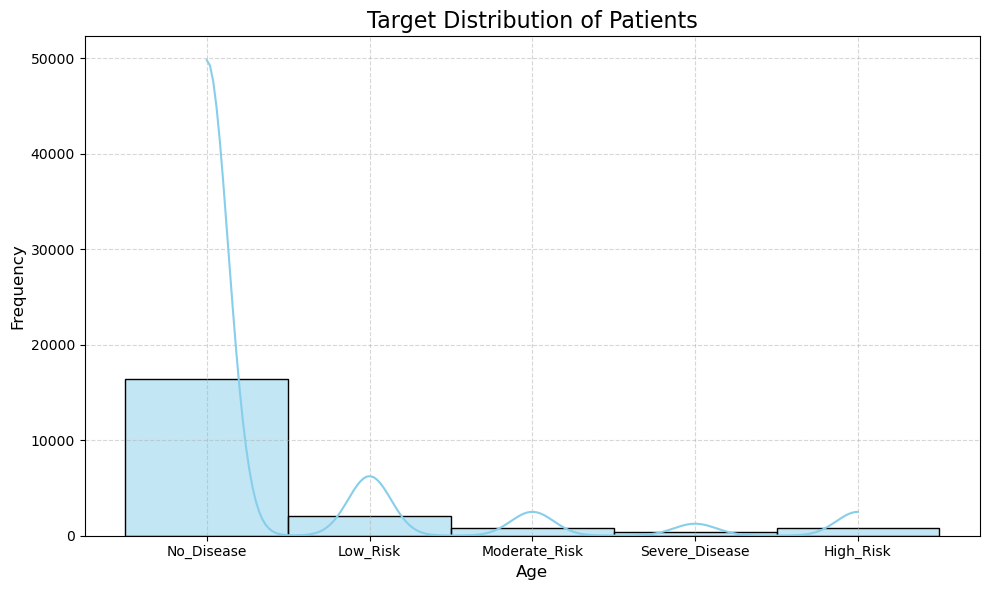

In [140]:
#target distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['Target'], kde=True, color='skyblue', bins=30)
plt.title('Target Distribution of Patients', fontsize=16)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

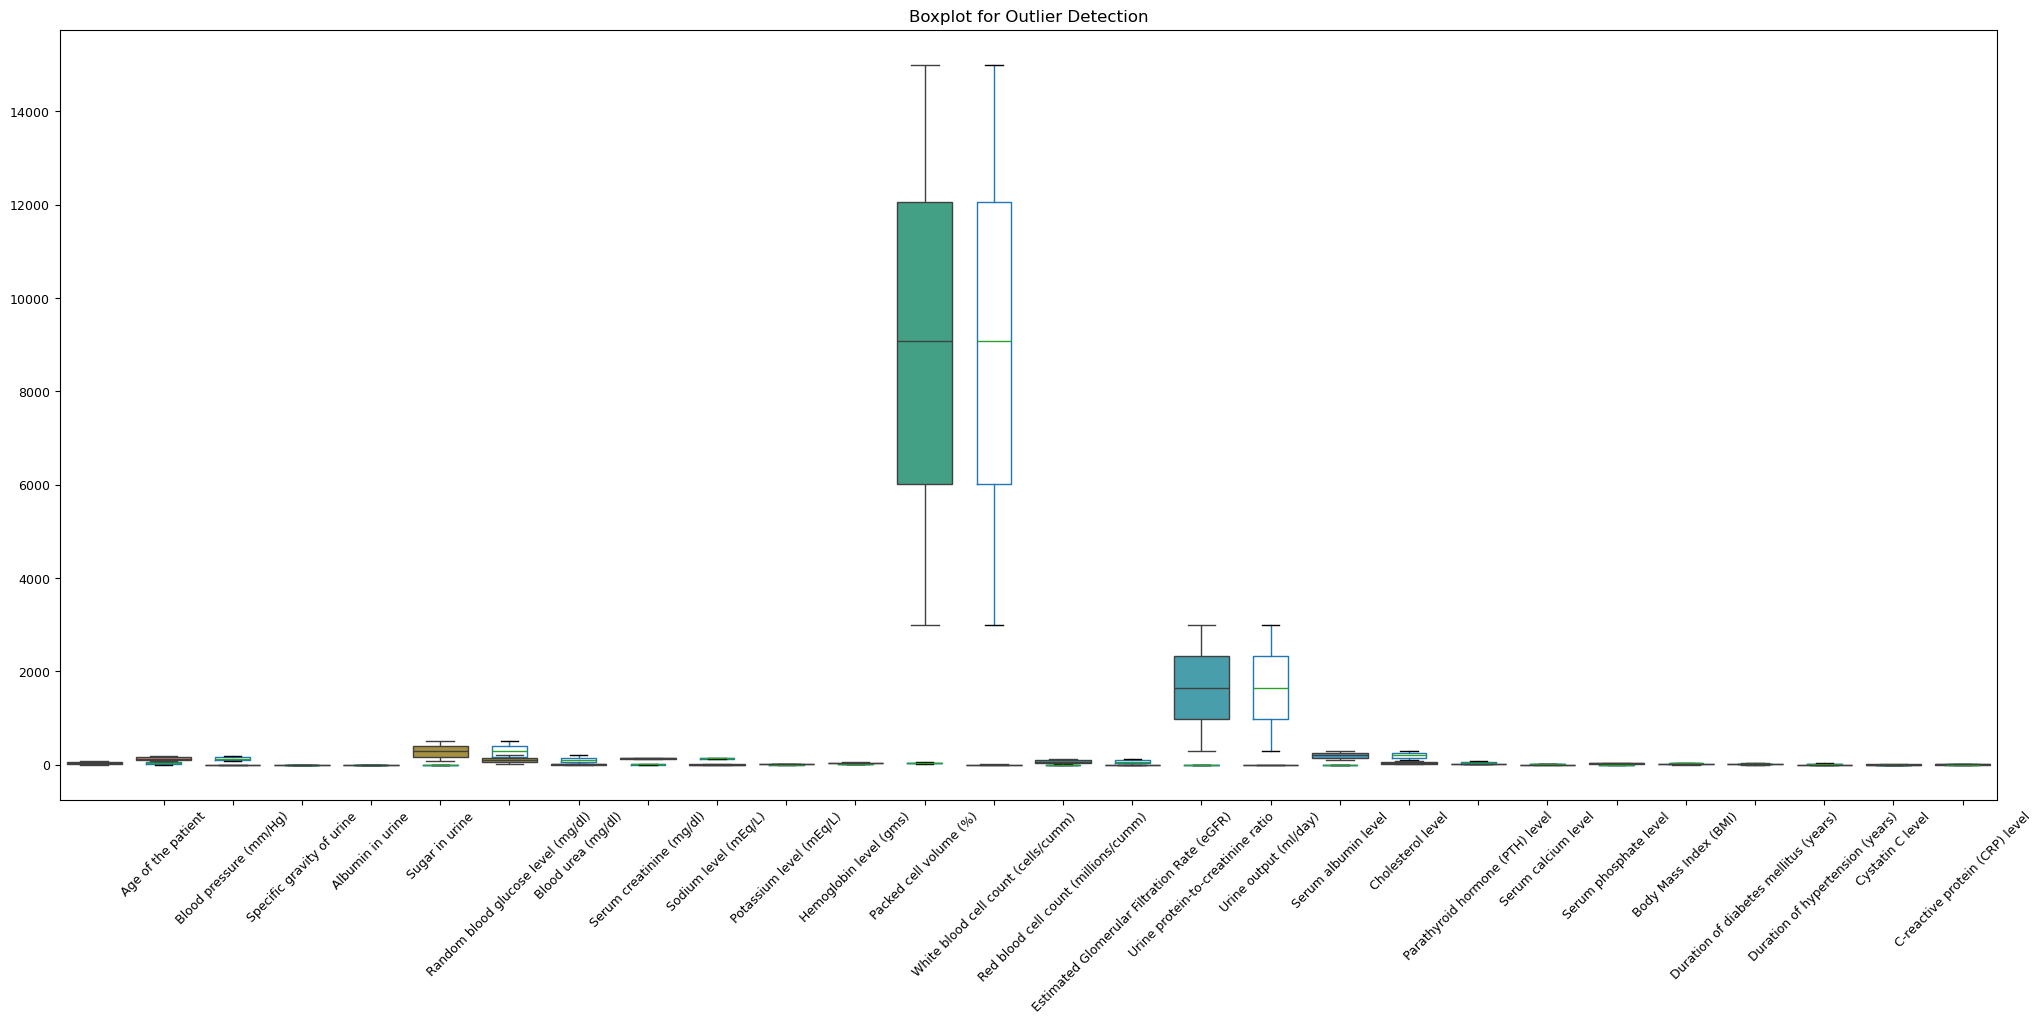

In [141]:
#boxplot for outliers
plt.figure(figsize=(25, 10))
boxplot = df.boxplot(grid=False, rot=45, fontsize=9)
sns.boxplot(data=df)
plt.title('Boxplot for Outlier Detection')
plt.show()


Target Variable Distribution ('Target'):
Target
No_Disease        16432
Low_Risk           2054
Moderate_Risk       821
High_Risk           821
Severe_Disease      410
Name: count, dtype: int64


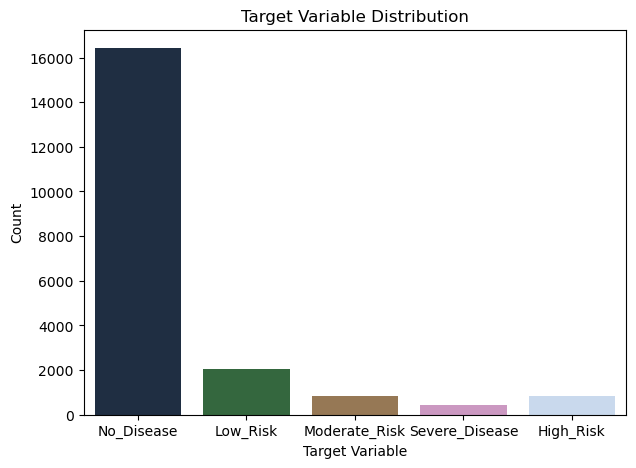

In [142]:
#another version of target distribution 
print(f"\nTarget Variable Distribution ('{target_column}'):")
print(df[target_column].value_counts())
plt.figure(figsize=(7, 5))
sns.countplot(x=target_column, data=df, palette = "cubehelix")
plt.title(f'Target Variable Distribution')
plt.xlabel('Target Variable')
plt.ylabel('Count')
plt.show()

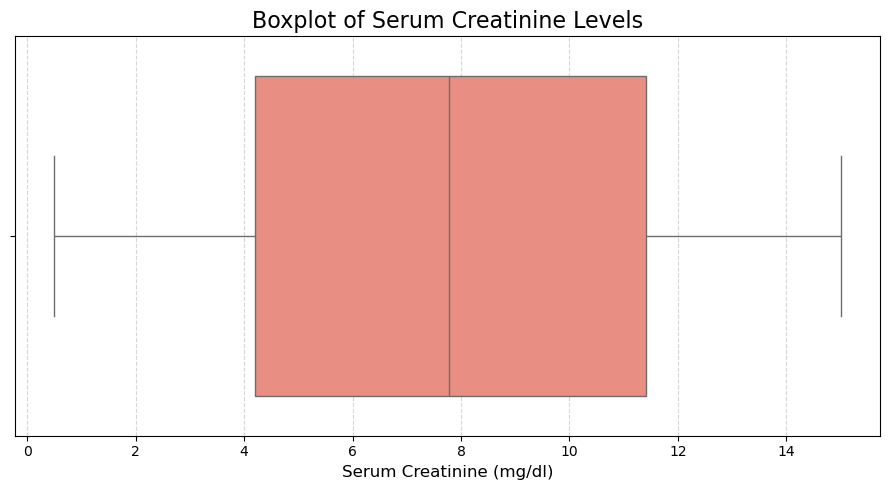

In [143]:
#boxplot for serum creatinine levels
plt.figure(figsize=(9, 5))
sns.boxplot(x=df['Serum creatinine (mg/dl)'], color='salmon')
plt.title('Boxplot of Serum Creatinine Levels', fontsize=16)
plt.xlabel('Serum Creatinine (mg/dl)', fontsize=12)
plt.grid(True, axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [144]:
# Computing Z-scores
z_scores = stats.zscore(df.select_dtypes(include=['number']))

# Identifing outliers
outliers = (abs(z_scores) > 3).any(axis=1)

# Removing outliers
df_no_outliers = df[~outliers]

print("Original size:", df.shape, "After outlier removal:", df_no_outliers.shape)

Original size: (20538, 43) After outlier removal: (20538, 43)


In [145]:
# Identify categorical columns
cat_cols = df.select_dtypes(include='object').columns.tolist()
num_cols = df.select_dtypes(include=np.number).columns.tolist()

# Impute numerical columns
num_imputer = SimpleImputer(strategy='mean')
df[num_cols] = num_imputer.fit_transform(df[num_cols])

# Impute categorical columns 
if cat_cols:
    cat_imputer = SimpleImputer(strategy='most_frequent')
    df[cat_cols] = pd.DataFrame(cat_imputer.fit_transform(df[cat_cols]), columns=cat_cols, index=df.index)


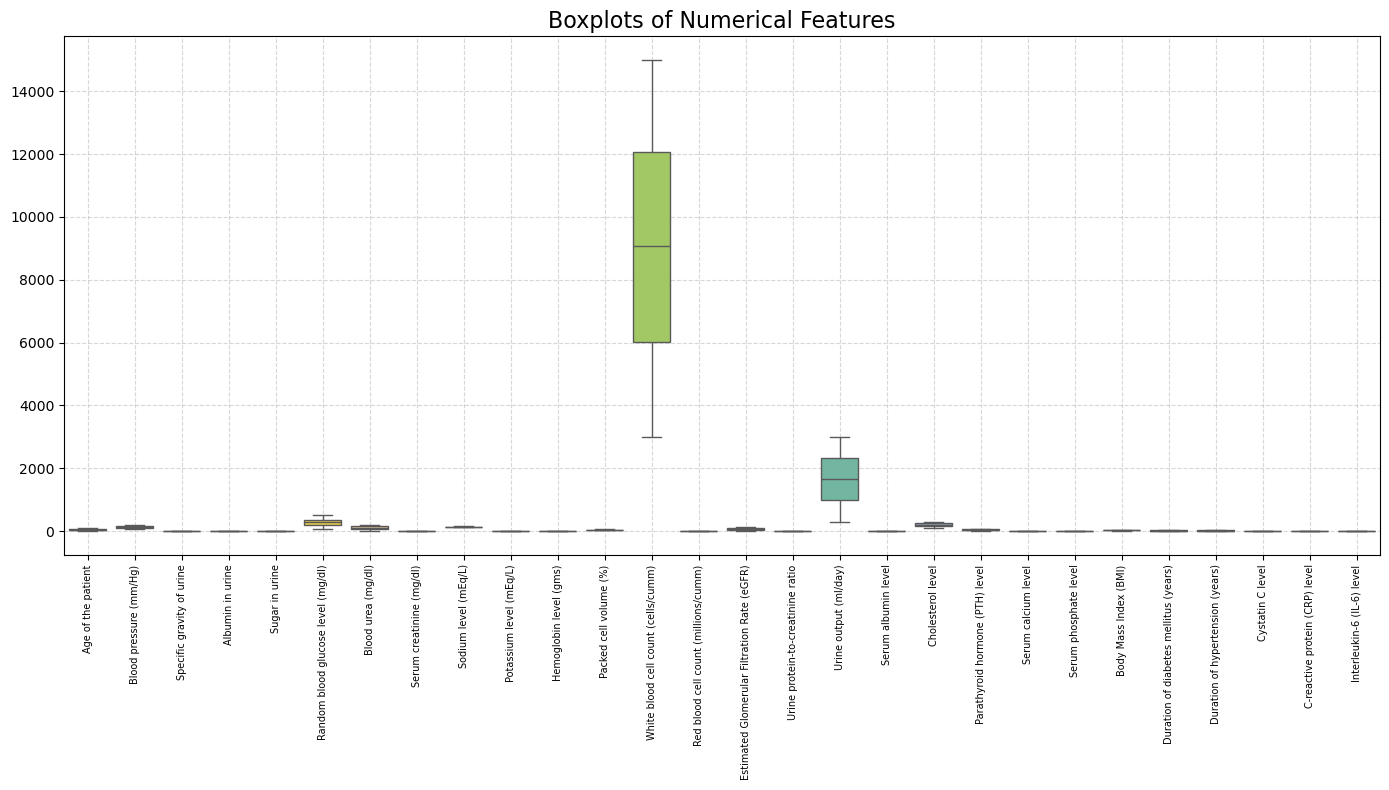

In [146]:
#boxplot for numerical features
plt.figure(figsize=(14, 8))
sns.boxplot(data=df[num_cols], palette='Set2')
plt.xticks(rotation=90, fontsize=7)
plt.title('Boxplots of Numerical Features', fontsize=16)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [147]:
# Encoding categorical columns 
for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

In [148]:
#defining features
y = df['Target']
X = df.drop('Target', axis=1)
feature_names = X.columns #to save column names

In [149]:
#splitting features
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

In [150]:
#applying SMOTE
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

Before SMOTE:
Target
3    80.007790
1    10.000974
2     3.997468
0     3.997468
4     1.996300
Name: proportion, dtype: float64

After SMOTE (training set only):
Target
3    20.0
1    20.0
4    20.0
0    20.0
2    20.0
Name: proportion, dtype: float64


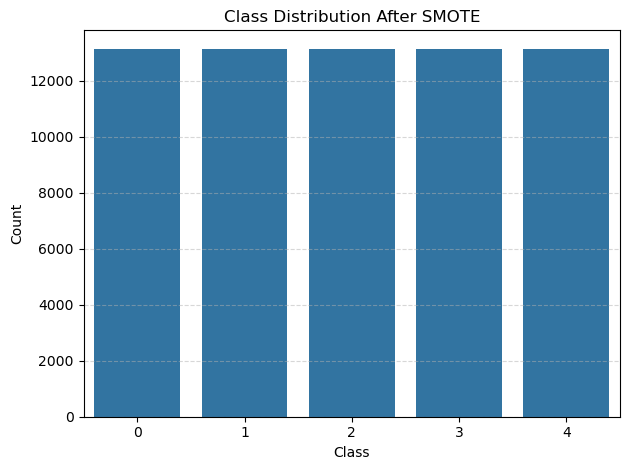

In [151]:
# Check Class Balance
print("Before SMOTE:")
print(y.value_counts(normalize=True) * 100)

print("\nAfter SMOTE (training set only):")
print(pd.Series(y_train).value_counts(normalize=True) * 100)

sns.countplot(x=y_train)
plt.title("Class Distribution After SMOTE")
plt.xlabel("Class")
plt.ylabel("Count")
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


In [152]:
#training features
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [153]:
#scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

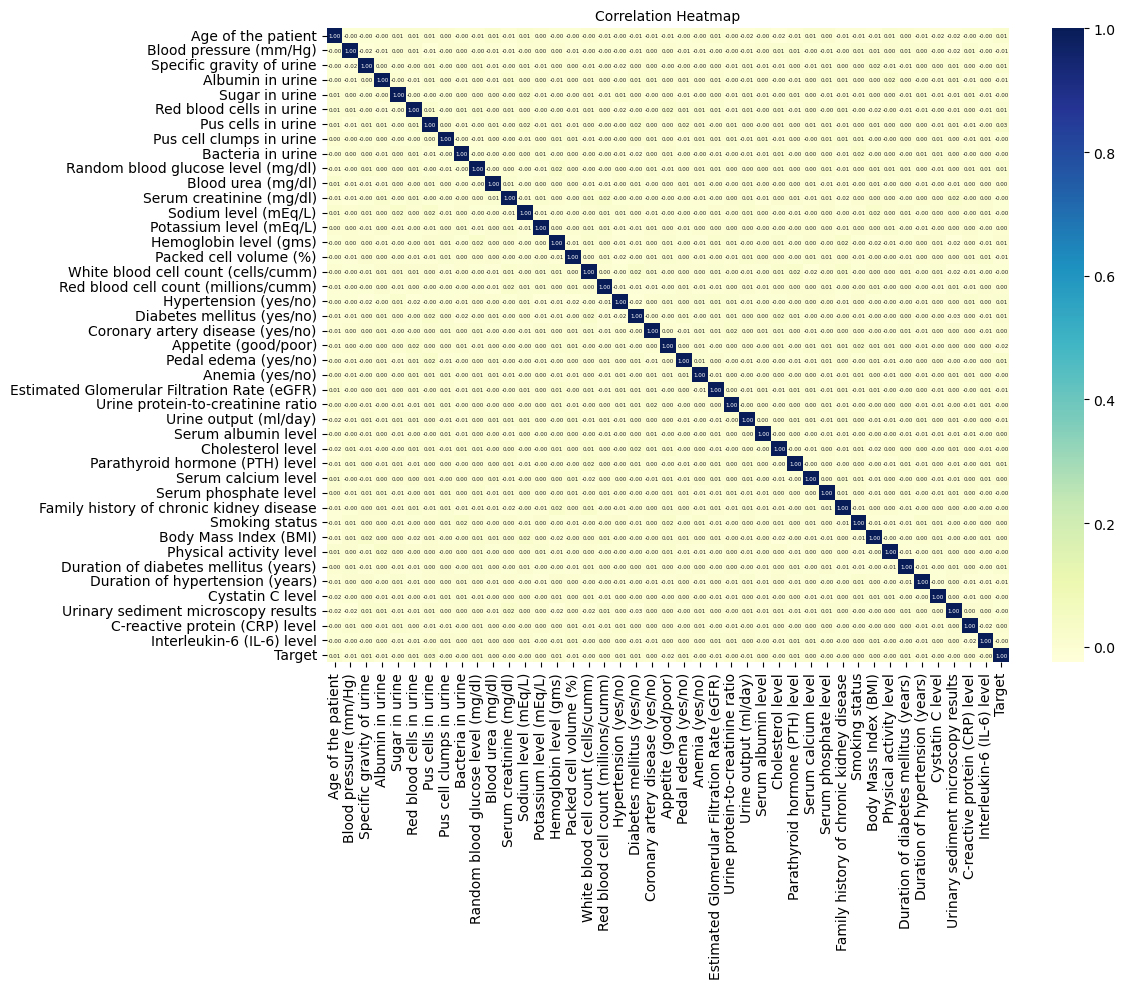

In [154]:
#correlation heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), annot=True, cmap='YlGnBu', fmt=".2f", annot_kws={"size": 4})
plt.title('Correlation Heatmap', fontsize=10)
plt.tight_layout()
plt.show()

In [155]:
# Helper functions
def run_cross_validation(model, X, y):
    scores = cross_val_score(model, X, y, cv=5, scoring='f1_weighted')
    print(f"Cross-validated F1 Score: {np.mean(scores):.4f} (+/- {np.std(scores):.4f})\n")


In [156]:
#initializing
scaler = StandardScaler()

In [157]:
#training different models and evualating them
#logistic regression
log_model = LogisticRegression()
log_model.fit(X_train, y_train)
log_pred = log_model.predict(X_test)
log_proba = log_model.predict_proba(X_test)[:, 1]
print(classification_report(y_test, log_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       168
           1       0.00      0.00      0.00       416
           2       0.00      0.00      0.00       155
           3       0.80      1.00      0.89      3296
           4       0.00      0.00      0.00        73

    accuracy                           0.80      4108
   macro avg       0.16      0.20      0.18      4108
weighted avg       0.64      0.80      0.71      4108



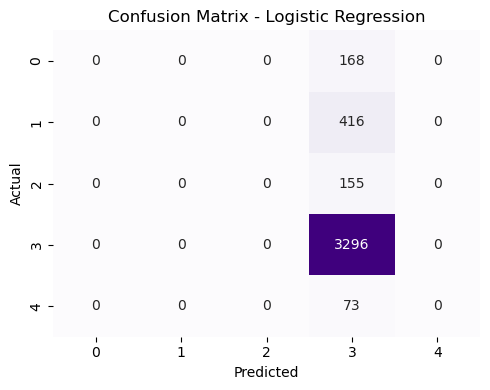

In [158]:
#confusion matrix 
cm = confusion_matrix(y_test, log_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', cbar=False)
plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

In [159]:
#Decision Tree
dt_model = DecisionTreeClassifier()
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)
dt_proba = dt_model.predict_proba(X_test)[:, 1]
print(classification_report(y_test, dt_pred))

              precision    recall  f1-score   support

           0       0.04      0.04      0.04       168
           1       0.09      0.10      0.09       416
           2       0.03      0.04      0.04       155
           3       0.80      0.76      0.78      3296
           4       0.01      0.01      0.01        73

    accuracy                           0.62      4108
   macro avg       0.19      0.19      0.19      4108
weighted avg       0.65      0.62      0.64      4108



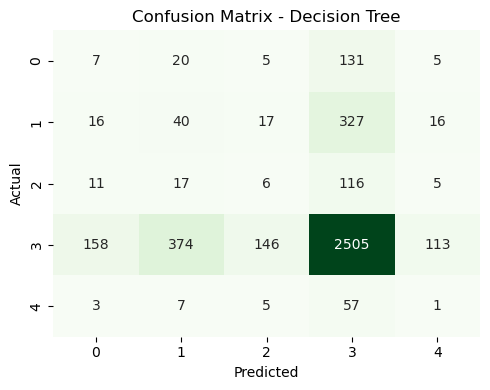

In [160]:
#confusion matrix
cm = confusion_matrix(y_test, dt_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', cbar=False)
plt.title("Confusion Matrix - Decision Tree")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

In [161]:
#Random Forest
rf_model = RandomForestClassifier()
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_proba = rf_model.predict_proba(X_test)[:, 1]
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       168
           1       0.00      0.00      0.00       416
           2       0.00      0.00      0.00       155
           3       0.80      1.00      0.89      3296
           4       0.00      0.00      0.00        73

    accuracy                           0.80      4108
   macro avg       0.16      0.20      0.18      4108
weighted avg       0.64      0.80      0.71      4108



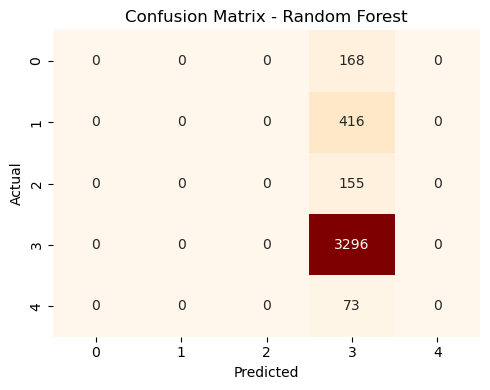

In [162]:
#confusion matrix
cm = confusion_matrix(y_test, rf_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='OrRd', cbar=False)
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

In [163]:
#XGboost
xgb_model = xgb.XGBClassifier(eval_metric='logloss')
xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)
xgb_proba = xgb_model.predict_proba(X_test)[:, 1]
print(classification_report(y_test, xgb_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       168
           1       0.00      0.00      0.00       416
           2       0.00      0.00      0.00       155
           3       0.80      1.00      0.89      3296
           4       0.00      0.00      0.00        73

    accuracy                           0.80      4108
   macro avg       0.16      0.20      0.18      4108
weighted avg       0.64      0.80      0.71      4108



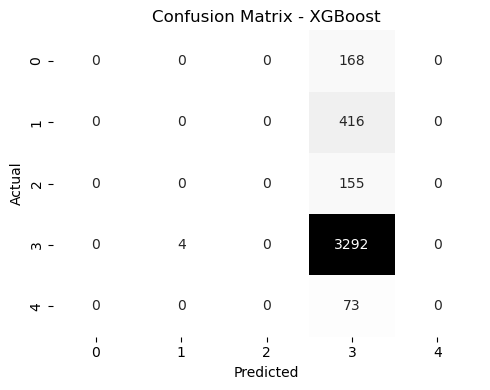

In [164]:
#confusion matrix
cm = confusion_matrix(y_test, xgb_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greys', cbar=False)
plt.title("Confusion Matrix - XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

In [165]:
#Grid Search for Logistic regression
print("\n Logistic Regression")
log_params = {'C': [0.1, 1, 10]}
log_model = GridSearchCV(LogisticRegression(), log_params, cv=5, scoring='f1_weighted')
run_cross_validation(log_model, X_train, y_train)
log_model.fit(X_train, y_train)
print(classification_report(y_test, log_model.best_estimator_.predict(X_test)))
print(f"Best Parameters for Logistic Regression: {log_model.best_params_}\n")


 Logistic Regression
Cross-validated F1 Score: 0.7104 (+/- 0.0002)

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       168
           1       0.00      0.00      0.00       416
           2       0.00      0.00      0.00       155
           3       0.80      1.00      0.89      3296
           4       0.00      0.00      0.00        73

    accuracy                           0.80      4108
   macro avg       0.16      0.20      0.18      4108
weighted avg       0.64      0.80      0.71      4108

Best Parameters for Logistic Regression: {'C': 0.1}



In [166]:
#Grid search for Decision Tree
print("\n Decision Tree")
dt_params = {'max_depth': [3, 5, 10]}
dt_model = GridSearchCV(DecisionTreeClassifier(), dt_params, cv=5, scoring='f1_weighted')
run_cross_validation(dt_model, X_train, y_train)
dt_model.fit(X_train, y_train)
print(classification_report(y_test, dt_model.best_estimator_.predict(X_test)))
print(f"Best Parameters for Decision Tree: {dt_model.best_params_}\n")


 Decision Tree
Cross-validated F1 Score: 0.7098 (+/- 0.0009)

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       168
           1       0.00      0.00      0.00       416
           2       0.00      0.00      0.00       155
           3       0.80      1.00      0.89      3296
           4       0.00      0.00      0.00        73

    accuracy                           0.80      4108
   macro avg       0.16      0.20      0.18      4108
weighted avg       0.64      0.80      0.71      4108

Best Parameters for Decision Tree: {'max_depth': 3}



In [167]:
#Grid search for random forest
print("\n Random Forest")
rf_params = {'n_estimators': [100, 200], 'max_depth': [5, 10]}
rf_model = GridSearchCV(RandomForestClassifier(), rf_params, cv=5, scoring='f1_weighted')
run_cross_validation(rf_model, X_train, y_train)
rf_model.fit(X_train, y_train)
print(classification_report(y_test, rf_model.best_estimator_.predict(X_test)))
print(f"Best Parameters for Random Forest: {rf_model.best_params_}\n")


 Random Forest
Cross-validated F1 Score: 0.7104 (+/- 0.0002)

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       168
           1       0.00      0.00      0.00       416
           2       0.00      0.00      0.00       155
           3       0.80      1.00      0.89      3296
           4       0.00      0.00      0.00        73

    accuracy                           0.80      4108
   macro avg       0.16      0.20      0.18      4108
weighted avg       0.64      0.80      0.71      4108

Best Parameters for Random Forest: {'max_depth': 5, 'n_estimators': 100}



In [168]:
#Grid search for XGBoost
print("\n XGBoost")
xgb_params = {'n_estimators': [100, 200], 'max_depth': [3, 6]}
xgb_model = GridSearchCV(xgb.XGBClassifier(eval_metric='logloss'), xgb_params, cv=5, scoring='f1_weighted')
run_cross_validation(xgb_model, X_train, y_train)
xgb_model.fit(X_train, y_train)
print(classification_report(y_test, xgb_model.best_estimator_.predict(X_test)))
print(f"Best Parameters for XGBoost: {xgb_model.best_params_}\n")


 XGBoost
Cross-validated F1 Score: 0.7105 (+/- 0.0002)

              precision    recall  f1-score   support

           0       0.00      0.00      0.00       168
           1       0.00      0.00      0.00       416
           2       0.00      0.00      0.00       155
           3       0.80      1.00      0.89      3296
           4       0.00      0.00      0.00        73

    accuracy                           0.80      4108
   macro avg       0.16      0.20      0.18      4108
weighted avg       0.64      0.80      0.71      4108

Best Parameters for XGBoost: {'max_depth': 6, 'n_estimators': 200}



In [178]:
tuned_models = {
    "Logistic Regression": log_model.best_estimator_,
    "Decision Tree": dt_model.best_estimator_,
    "Random Forest": rf_model.best_estimator_,
    "XGBoost": xgb_model.best_estimator_,
}

summary = []
for name, model in models.items():
    y_pred = model.predict(X_test)
    summary.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, average='weighted'),
        "Recall": recall_score(y_test, y_pred, average='weighted'),
        "F1 Score": f1_score(y_test, y_pred, average='weighted')
    })

In [180]:
summary_df = pd.DataFrame(summary).set_index("Model")
print("Final Model Performance Summary:")
print(summary_df.sort_values(by="F1 Score", ascending=False))

Final Model Performance Summary:
                     Accuracy  Precision    Recall  F1 Score
Model                                                       
Logistic Regression  0.802337   0.643745  0.802337  0.714344
Decision Tree        0.802337   0.643745  0.802337  0.714344
Random Forest        0.802337   0.643745  0.802337  0.714344
XGBoost              0.800633   0.643474  0.800633  0.713502


In [182]:
best_model_name = summary_df.sort_values(by="F1 Score", ascending=False).index[0]
best_model = models[best_model_name]
joblib.dump(best_model, f"best_model_{best_model_name.replace(' ', '_').lower()}.pkl")
print(f" Best model '{best_model_name}' saved successfully!")

 Best model 'Logistic Regression' saved successfully!


Multiclass ROC AUC Score (Logistic Regression): 0.5097


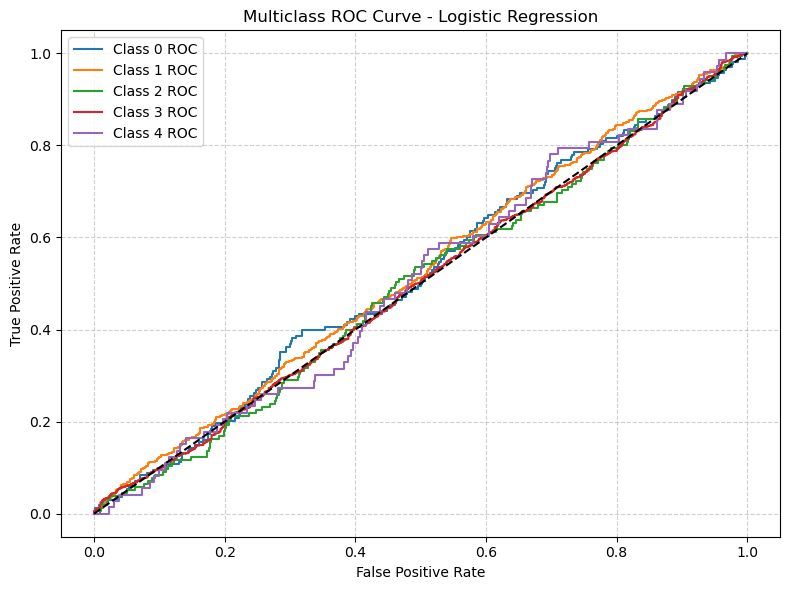

Multiclass ROC AUC Score (Decision Tree): 0.5049


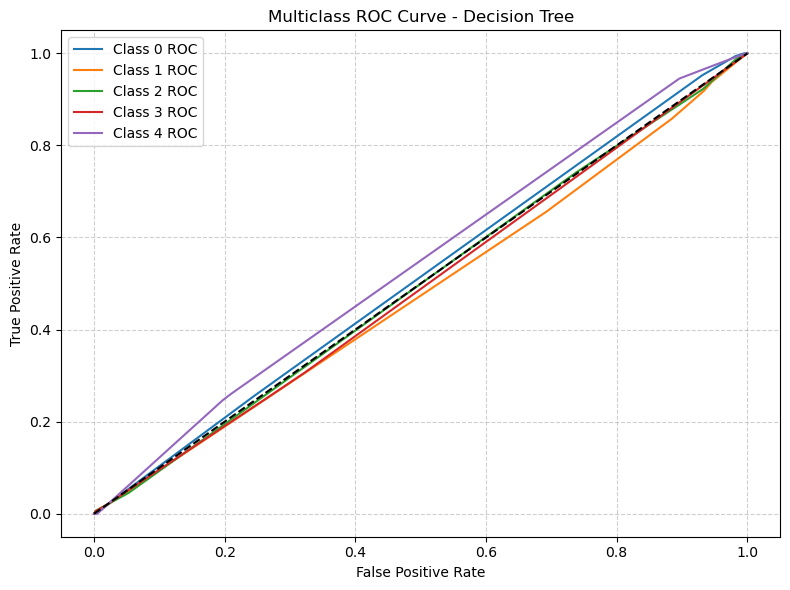

Multiclass ROC AUC Score (Random Forest): 0.4879


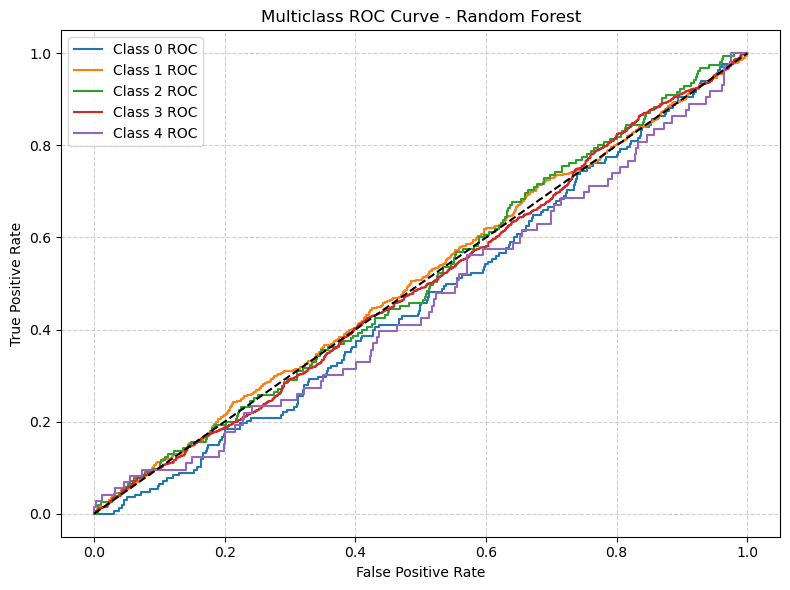

Multiclass ROC AUC Score (XGBoost): 0.5094


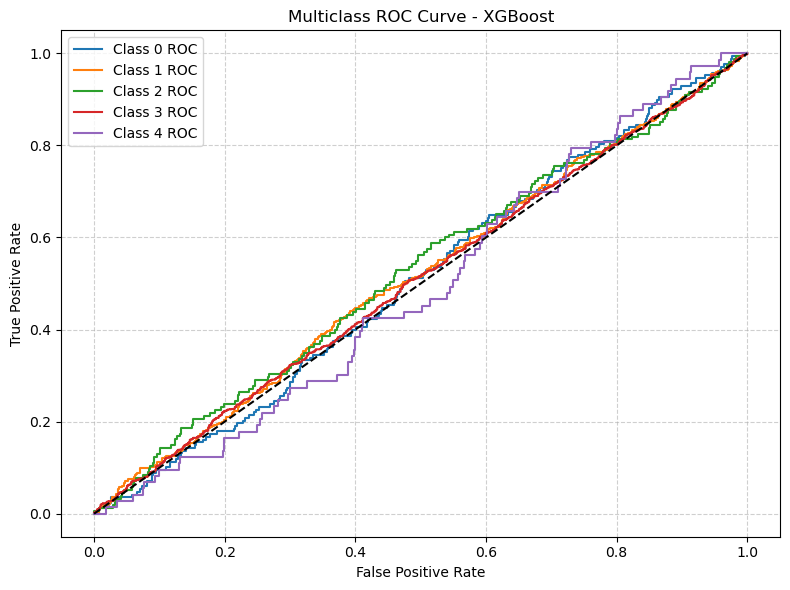

In [184]:
#ROC-AUC curve for all models with all classes
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve

if len(np.unique(y_test)) > 2:
    y_test_bin = label_binarize(y_test, classes=np.unique(y_test))
    for name, model in models.items():
        if hasattr(model, 'predict_proba'):
            y_proba = model.predict_proba(X_test)
            auc = roc_auc_score(y_test_bin, y_proba, average="macro", multi_class="ovr")
            print(f"Multiclass ROC AUC Score ({name}): {auc:.4f}")

            fpr = dict()
            tpr = dict()
            for i in range(y_test_bin.shape[1]):
                fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_proba[:, i])

            plt.figure(figsize=(8, 6))
            for i in range(y_test_bin.shape[1]):
                plt.plot(fpr[i], tpr[i], label=f"Class {i} ROC")
            plt.plot([0, 1], [0, 1], 'k--')
            plt.title(f"Multiclass ROC Curve - {name}")
            plt.xlabel("False Positive Rate")
            plt.ylabel("True Positive Rate")
            plt.legend()
            plt.grid(True, linestyle='--', alpha=0.6)
            plt.tight_layout()
            plt.show()

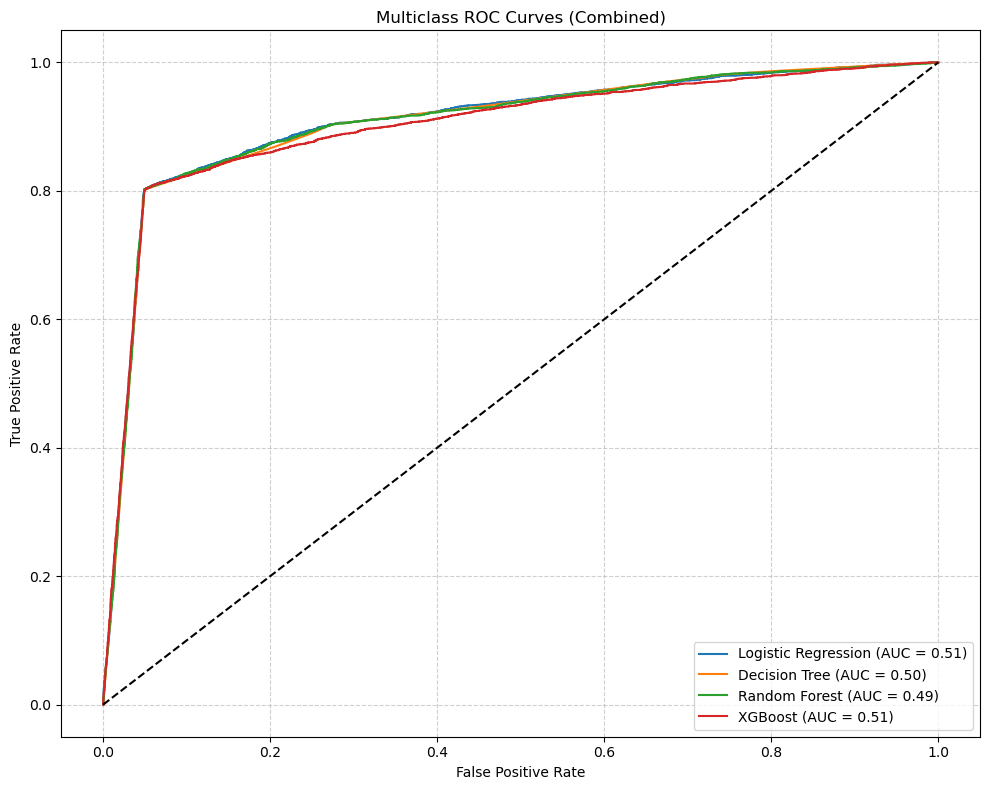

In [185]:
#one ROC-AUC curve all models combined
if len(np.unique(y_test)) > 2:
    y_test_bin = label_binarize(y_test, classes=np.unique(y_test))
    plt.figure(figsize=(10, 8))

    for name, model in models.items():
        if hasattr(model, 'predict_proba'):
            y_proba = model.predict_proba(X_test)
            auc = roc_auc_score(y_test_bin, y_proba, average="macro", multi_class="ovr")
            fpr, tpr, _ = roc_curve(y_test_bin.ravel(), y_proba.ravel())
            plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.2f})")

    plt.plot([0, 1], [0, 1], 'k--')
    plt.title("Multiclass ROC Curves (Combined)")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

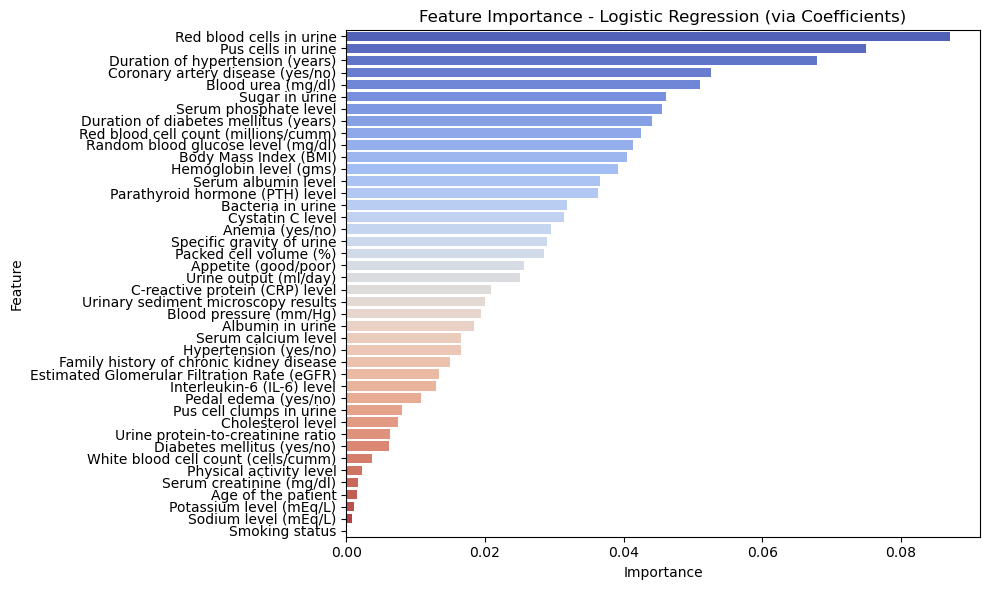

In [201]:
#feature importance for logistic regression
log_coefs = log_model.best_estimator_.coef_[0]

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': np.abs(log_coefs)  
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='coolwarm')
plt.title('Feature Importance - Logistic Regression (via Coefficients)')
plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

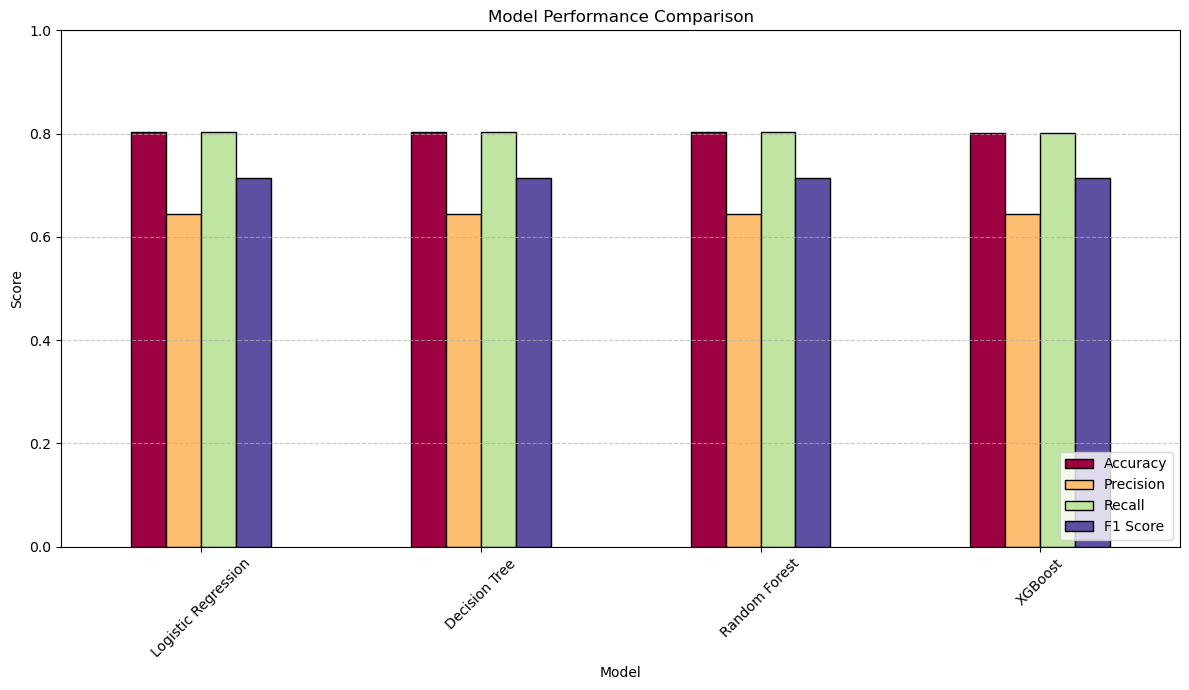

In [190]:
#barplot model comparison
plt.figure(figsize=(10, 6))
summary_df.sort_values(by='F1 Score', ascending=False)[['Accuracy', 'Precision', 'Recall', 'F1 Score']].plot(
    kind='bar', figsize=(12, 7), colormap='Spectral', edgecolor='black')
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.legend(loc='lower right')
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [193]:
# Determine the best model based on F1 Score
best_model_name = summary_df.sort_values(by="F1 Score", ascending=False).index[0]
best_tuned_pipeline = tuned_models[best_model_name]

print(f"\nSelected best model for deployment: {best_model_name}")

# Define the project root and create a 'models' directory if it doesn't exist
project_root = os.getcwd() # Use current working directory as project root for relative paths
models_dir = os.path.join(project_root, 'models')
os.makedirs(models_dir, exist_ok=True)

# Save the best model pipeline
model_pipeline_path = os.path.join(models_dir, 'kidney_disease_pipeline.pkl')
joblib.dump(best_tuned_pipeline, model_pipeline_path)
print(f"Complete model pipeline saved to '{model_pipeline_path}'")

# Save feature names
feature_names_path = os.path.join(models_dir, 'feature_names.pkl')
joblib.dump(feature_names.tolist(), feature_names_path) # Convert to list for simpler serialization
print(f"Feature names saved to '{feature_names_path}'")

print("\nConclusion: The project successfully trained and evaluated several machine learning models for kidney disease prediction. Hyperparameter tuning was performed using GridSearchCV to optimize model performance. The best performing model, based on F1-score, was saved as a complete pipeline, along with the feature names, for future deployment.")



Selected best model for deployment: Logistic Regression
Complete model pipeline saved to 'C:\Users\LENOVO\models\kidney_disease_pipeline.pkl'
Feature names saved to 'C:\Users\LENOVO\models\feature_names.pkl'

Conclusion: The project successfully trained and evaluated several machine learning models for kidney disease prediction. Hyperparameter tuning was performed using GridSearchCV to optimize model performance. The best performing model, based on F1-score, was saved as a complete pipeline, along with the feature names, for future deployment.
